In [18]:
%load_ext autoreload
%autoreload 2
import os,sys 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as pat
import json 
def find_root_path(path:str, word:str):
    parts = path.split(word, 1)
    return parts[0] + word if len(parts) > 1 else path 
root_folder = find_root_path(os.getcwd(), 'art_lang')
sys.path.append(root_folder)

import rpod.optimization.parameters as param    
from rpod.optimization.scvx import solve_scvx
from rpod.dynamics.dynamics_trans import *
from rpod.dynamics.dynamics_rot import *
from rpod.optimization.optimization import NonConvexOCP
from rpod.optimization.utils import plot_ellipse
from test_render import *

# %matplotlib qt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [57]:
# sample boundary conditions 
behavior_mode, roe0, roef, t_idx_wyp, wyp = param.sample_reset_condition2(behavior=3)
print(f"Behavior mode: {behavior_mode}, waypoint time index: {t_idx_wyp}")

# dummy initial and final conditions for testing
# roe0 = np.array([-1,-40, 0,0,0,0])
# roef = np.array([-1,40,0,0,0,0])
# t_idx_wyp = []
# wyp = []

current_obs = {'state':roe0, 'goal':roef, 'ttg':param.tf_sec, 'dt':param.dt_sec, 'oe':param.oec0}
chance = True
ct = False

oec = propagate_oe(param.oec0, param.tvec_sec)
tvec_sec = param.tvec_sec
# Aliases
period = param.period
n_time = param.n_time
n_safe = param.n_safe
dt_safe_sec = param.dt_safe_sec
t_safe_sec = param.t_safe_sec
DEED = param.DEED
invICDF = param.invICDF

Behavior mode: 3, waypoint time index: [11, 44]


In [58]:
# Step 1: Solve convex problem to get initial guess
prob = NonConvexOCP(
    prob_definition={
        't_i' : 0,  # Initial time INDEX (0-based index into tvec_sec array)
        't_f' : n_time,  # Final time INDEX (0-based index into tvec_sec array, should be the size of the array)
        'tvec_sec' : param.tvec_sec,  # Array of time values in seconds (e.g., np.linspace output with n_time_rpod elements)
        'chance' : chance,
        'current_obs' : current_obs,
        'waypoint_times' : t_idx_wyp,
        'waypoints' : wyp,
        'ct':ct, 
    }
)

In [59]:
# Solve convex problem to get initial guess
sol_cvx = prob.ocp_cvx()
print(f"Convex solution status: {sol_cvx['status']}")
print(f"Convex solution cost: {sol_cvx['cost']:.3f} m/s")

roe_cvx = sol_cvx["z"]["state"]
u_cvx = sol_cvx["z"]["action"]
rtn_cvx = prob.f_2rtn(roe_cvx, oec)
cost = np.sum(np.linalg.norm(u_cvx, axis=1)) 
print(f"Final cost: {cost:.3f} m/s")
s_roe_ps0, s_rtn_ps0, Σ_roe_ps0, Σ_rtn_ps0, _, constr_ps0 = prob.eval_ps(roe_cvx, u_cvx, prob.tvec_sec, chance=chance, ct=ct)   
ctg, _ = prob.compute_ctg(roe_cvx, u_cvx, prob.tvec_sec, chance=chance)
rtg = prob.compute_rtg(u_cvx)
rtn_cvx = prob.f_2rtn(roe_cvx, oec)
t_cvx_ct, roe_cvx_ct, rtn_cvx_ct = prob.propagate_ct(roe_cvx, u_cvx, param.tvec_sec, n=20)

roe_cvx_aug = np.vstack([roe_cvx, roe_cvx[-1]+cim_roe(oec[-1])@u_cvx[-1]])  # for plotting CIM


Convex solution status: optimal
Convex solution cost: 0.074 m/s
Final cost: 0.074 m/s


In [61]:
# solve the SCP 
prob.zref = {'state': roe_cvx, 'action': u_cvx}
prob.sol_0 = {"z": prob.zref}
prob.verbose_scvx = True
prob.verbose = False
prob.generate_scaling(roe_cvx, u_cvx)

t0 = time.time()
sol_scp, log_scp = solve_scvx(prob)
elapsed_time = time.time() - t0

roe_scp = sol_scp["z"]["state"]
u_scp = sol_scp["z"]["action"]
rtn_scp = prob.f_2rtn(roe_scp, oec)
roe_scp_aug = np.vstack([roe_scp, roe_scp[-1]+cim_roe(oec[-1])@u_scp[-1]])  # for plotting CIM
t_scp_ct, roe_scp_ct, rtn_scp_ct = prob.propagate_ct(roe_scp, u_scp, param.tvec_sec, n=20)

print(f"SCP runtime: {elapsed_time:.3f} sec, iterations: {len(log_scp['f0'])}")
print(f"SCP solution status: {sol_scp['status']}")
print(f"SCP solution cost: {sol_scp['cost']:.3f} m/s")

-------------------------------------------------------------------------------------------------------------------------------
Iter  ||     χ     |    ΔJ     ||     L     |    f0     |     P     |     r     |     w     |    ρk     |    ΔL     |     δ    
-------------------------------------------------------------------------------------------------------------------------------
  0   ||  9.70e-04 | +4.40e+01 ||  8.93e-02 |  8.93e-02 |  4.59e-07 | +2.50e-01 | +1.00e+01 | +1.00e+00 | +4.40e+01 |       inf
  1   ||  6.38e-03 | -3.28e-04 ||  8.93e-02 |  8.93e-02 |  7.24e-08 | +5.00e-01 | +1.50e+01 | -1.72e+01 | +1.91e-05 |  4.40e+01
  2   ||  6.38e-03 | -3.28e-04 ||  8.93e-02 |  8.93e-02 |  7.24e-08 | +2.50e-01 | +1.50e+01 | -1.72e+01 | +1.91e-05 |  4.40e+01
  3   ||  6.38e-03 | -3.28e-04 ||  8.93e-02 |  8.93e-02 |  7.24e-08 | +1.25e-01 | +1.50e+01 | -1.72e+01 | +1.91e-05 |  4.40e+01
  4   ||  6.38e-03 | -3.28e-04 ||  8.93e-02 |  8.93e-02 |  7.24e-08 | +6.25e-02 | +1.50e+01 | -1.72e+01 

### plotting 

In [62]:
# option 1
# rtn_ct = rtn_cvx_ct
# rtn = rtn_cvx
# roe = roe_cvx
# roe_aug = roe_cvx_aug
# u = u_cvx

# option 2
rtn_ct = rtn_scp_ct
rtn = rtn_scp
roe = roe_scp
roe_aug = roe_scp_aug
u = u_scp

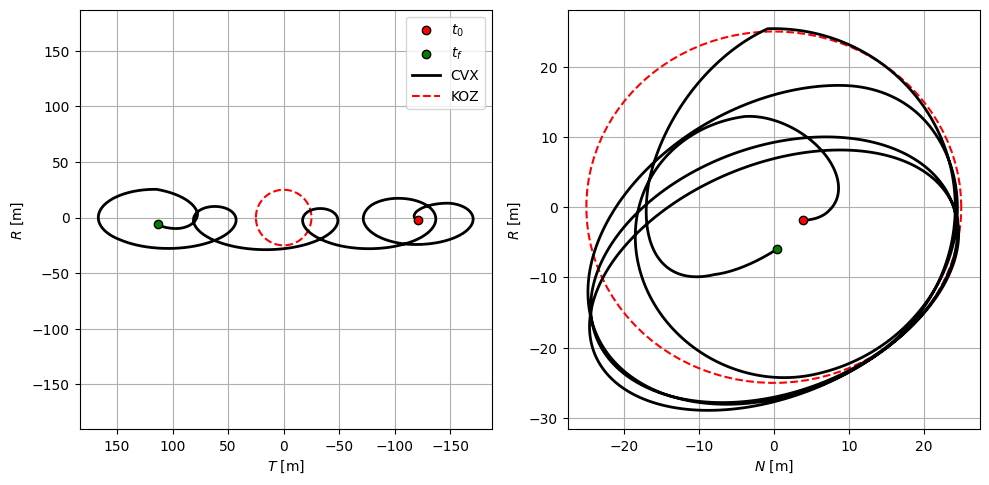

In [63]:
# plot helper for circle KOZ 
phi = np.linspace(0, 2*np.pi, 100)
x_circ = param.dim_koz[0][0] * np.cos(phi)
y_circ = param.dim_koz[0][0] * np.sin(phi)

fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(121)
ax1.scatter(rtn_ct[0,1], rtn_ct[0,0], marker = 'o', color='r', edgecolor='k', zorder=20, label='$t_0$')
ax1.scatter(rtn_ct[-1,1], rtn_ct[-1,0], marker = 'o', color='g', edgecolor='k',  zorder=20, label='$t_f$')
ax1.plot(rtn_ct[:,1], rtn_ct[:,0], color='k', linewidth=2, zorder=10, label='CVX')
# ax1.quiver(rtn_cvx[1,:], rtn_cvx[0,:], -u_cvx[1,:], u_cvx[0,:], color="b", linewidth=2, scale=30)
ax1.plot(x_circ, y_circ, color='r', linestyle='--', label='KOZ')
ax1.set_xlabel("$T$ [m]")
ax1.set_ylabel("$R$ [m]")
ax1.legend()
ax1.invert_xaxis()
ax1.grid()
ax1.axis('equal')
ax2 = fig.add_subplot(122)
ax2.scatter(rtn_ct[0,2], rtn_ct[0,0], marker = 'o', color='r', edgecolor='k', zorder=20, label='$t_0$')
ax2.scatter(rtn_ct[-1,2], rtn_ct[-1,0], marker = 'o', color='g', edgecolor='k',  zorder=20, label='$t_f$')
ax2.plot(rtn_ct[:,2], rtn_ct[:,0], color='k', linewidth=2, zorder=10, label='CVX')
# ax2.quiver(rtn_cvx[2,:], rtn_cvx[0,:], u_cvx[2,:], u_cvx[0,:], color="b", linewidth=2, scale=20)
ax2.plot(x_circ, y_circ, color='r', linestyle='--', label='KOZ')
ax2.set_xlabel("$N$ [m]")
ax2.set_ylabel("$R$ [m]")
ax2.grid()
# ax2.axis("equal")
fig.tight_layout()

In [64]:
qw_deputy2targ_rtn, _ = track_target(rtn, prob.tvec_sec, los=np.array([0,0,1]))
q_vbs2targ_rtn = qw_deputy2targ_rtn[:, :4]

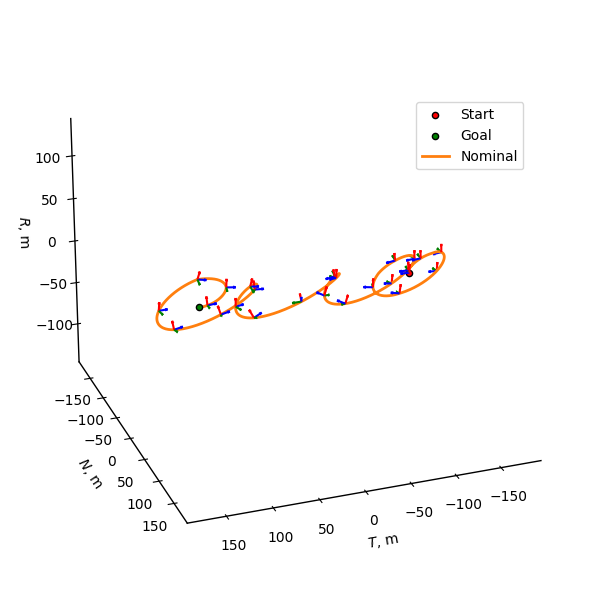

In [65]:
plot_3d = True
if plot_3d:
    
    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, projection='3d')
    
    phi = np.linspace(0, 2*np.pi, 100)
    x_circ = param.dim_koz[0][0] * np.cos(phi)
    y_circ = param.dim_koz[0][0] * np.sin(phi)
    
    ax.set_facecolor('white')
    ax.grid(False)
    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis.pane.fill = False
        axis.line.set_color('black')
        axis.line.set_linewidth(1)
    
    ax.scatter(rtn_ct[0,1], rtn_ct[0,2], rtn_ct[0,0],
               marker='o', color='r', edgecolor='k', zorder=20, label='Start')
    ax.scatter(rtn_ct[-1,1], rtn_ct[-1,2], rtn_ct[-1,0],
               marker='o', color='g', edgecolor='k', zorder=20, label='Goal')
    ax.plot(rtn_ct[:,1], rtn_ct[:,2], rtn_ct[:,0],
            color='C1', linewidth=2, zorder=10, label='Nominal')
    
    x_scp, y_scp, z_scp = rtn_ct[:,0], rtn_ct[:,1], rtn_ct[:,2]
    alpha = 0.7
    R_proj = -90; T_proj = -250; N_proj = -180
    # ax.plot(y_scp, z_scp, np.full_like(x_scp, R_proj), 'k-', alpha=alpha, linewidth=0.5)  # RT plane
    # ax.plot(y_scp, np.full_like(z_scp, N_proj), x_scp, 'k-', alpha=alpha, linewidth=0.5)  # RN plane
    # ax.plot(np.full_like(y_scp, T_proj), z_scp, x_scp, 'k-', alpha=alpha, linewidth=0.5)  # TN plane

    # # circle (kOZ) projection
    # ax.plot(y_circ, x_circ, np.full_like(x_circ, R_proj), 'r-', alpha=alpha, linewidth=0.5)
    # ax.plot(x_circ, np.full_like(x_circ, N_proj), y_circ, 'r-', alpha=alpha, linewidth=0.5)
    # ax.plot(np.full_like(x_circ, T_proj), y_circ, x_circ, 'r-', alpha=alpha, linewidth=0.5)
    
    # plot_ellipse(ax, np.array([param.dim_koz[0,1], param.dim_koz[0,2], param.dim_koz[0,0]]),
    #              pos=[0,0,0], Ndisc=20)

    n_time = rtn.shape[0]
    step   = max(n_time // 20, 1)             # plot at ~20 time steps
    axis_len = 0.4 * param.dim_koz[0,0]       # length of each axis vector

    for k in range(0, n_time, step):
        # rotation from deputy frame to RTN
        Rmat = q2dcm(q_vbs2targ_rtn[k])   # 3x3

        # columns are images of deputy x,y,z in RTN coordinates
        e_x = Rmat[:,0]   # deputy x-axis in RTN coords [R,T,N]
        e_y = Rmat[:,1]   # deputy y-axis in RTN coords
        e_z = Rmat[:,2]   # deputy z-axis in RTN coords

        # origin of axes at this time in RTN coordinates
        R0 = rtn[k,0]
        T0 = rtn[k,1]
        N0 = rtn[k,2]

        # Convert RTN ordering [R,T,N] -> plotting coords (T,N,R)
        # deputy x-axis (red)
        ax.quiver(T0, N0, R0,
                  axis_len * e_x[1], axis_len * e_x[2], axis_len * e_x[0], color='r')
        # deputy y-axis (green)
        ax.quiver(T0, N0, R0,
                  axis_len * e_y[1], axis_len * e_y[2], axis_len * e_y[0], color='g')
        # deputy z-axis (blue)
        ax.quiver(T0, N0, R0,
                  axis_len * e_z[1], axis_len * e_z[2], axis_len * e_z[0], color='b')
        
        # x-direction plotting 
        # scl = np.sqrt(T0**2 + N0**2 + R0**2) 
        # ax.plot([T0, T0 + e_x[1] * scl],
        #         [N0, N0 + e_x[2] * scl],
        #         [R0, R0 + e_x[0] * scl],
        #         color='k', linestyle='--', linewidth=0.5)

    ax.set_xlabel("$T$, m")
    ax.set_ylabel("$N$, m")
    ax.set_zlabel("$R$, m")
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.set_pane_color((1.0, 1.0, 1.0, 0))
    ax.view_init(elev=25, azim=70)
    ax.axis("equal")
    ax.legend(bbox_to_anchor=(0.7, 0.85), loc='upper left')

fig.tight_layout()

In [66]:
def dcm_eci2rtn(rv_c):
    # ECI->RTN rotation matrix
    R_hat = rv_c[0:3] / np.linalg.norm(rv_c[0:3])
    h     = np.cross(rv_c[0:3], rv_c[3:6])
    N_hat = h / np.linalg.norm(h)
    T_hat = np.cross(N_hat, R_hat)
    # rows are basis vectors of RTN expressed in ECI
    R_eci2rtn = np.vstack([R_hat, T_hat, N_hat])
    return R_eci2rtn

servicer_data_path = "/home/yuji/dataset/shirtv1/roe2/metadata.json"
with open(servicer_data_path, 'r') as f:
    servicer_data = json.load(f)

q_pri2vbs = np.array(servicer_data["pMdl"]["x1"]["q_pri2cam"])  # pri -> vbs
R_vbs2pri = q2dcm(q_conj(q_pri2vbs))

# get target ECI from the orbital elements 
oed = koeroe_to_koe(oec, roe/oec[0,0])
rv_eci2targ_eci = oe_to_pv(oec)
rv_eci2serv_eci = oe_to_pv(oed)
q_eci2pri       = np.zeros((n_time, 4))
q_vbs2targ_pri  = np.zeros((n_time, 4))
q_targ_pri2targ_rtn = np.zeros((n_time, 4))
r_serv2targ_vbs = np.zeros((n_time, 3))

# free tumbling 
qw0 = np.array([0.5, 0.5, 0.5, 0.5, 0.001, 0.0001, 0.001])
J = np.diag([1000, 1500, 2000])  # principal moments of inertia
qw = solve_ivp(dyn_qw, [0, param.tf_sec], qw0, args=(J,), t_eval=param.tvec_sec).y.T
q_targ_pri2targ_rtn = qw[:, :4]

for k in range(n_time):
    R_eci2serv_rtn = dcm_eci2rtn(rv_eci2serv_eci[k])
    R_eci2targ_rtn = dcm_eci2rtn(rv_eci2targ_eci[k])
    R_vbs2targ_rtn = q2dcm(q_vbs2targ_rtn[k]) 
    R_serv_rtn2targ_rtn = R_eci2targ_rtn @ R_eci2serv_rtn.T
    
    R_targ_pri2targ_rtn = q2dcm(q_targ_pri2targ_rtn[k])
    R_vbs2targ_pri = R_targ_pri2targ_rtn.T @ R_vbs2targ_rtn
    R_eci2pri = R_vbs2pri @ R_vbs2targ_rtn.T @ R_eci2targ_rtn
    # servicer's relative position / attitude 
    q_eci2pri[k] = dcm2q(R_eci2pri)
    q_vbs2targ_pri[k] = dcm2q(R_vbs2targ_pri)
    # q_targ_pri2targ_rtn[k] = dcm2q(R_targ_pri2targ_rtn)
    r_serv2targ_targ_rtn = - rtn[k, :3]
    r_serv2targ_vbs[k] = R_vbs2targ_rtn.T @ r_serv2targ_targ_rtn

In [67]:
save_dir = Path("/home/yuji/github/art_lang/rpod/sandbox/render/render_output")    
start_time = tobypy.date_gps(2028, 1, 1, 0, 0, 0)   # or your own start time

### Trajectory-Egocentric view coupled animation

In [68]:
render_with_traj_panel(
    r_serv2targ_vbs, q_vbs2targ_pri, rv_eci2serv_eci, q_eci2pri,
    rtn_ct, rtn, q_vbs2targ_rtn, q_targ_pri2targ_rtn,
    roe_aug, u, param.tvec_sec, 
    start_time_microsec=start_time,
    dt_sec=param.dt_sec,
    start_idx=0,
    max_images=50,
    save_dir=save_dir,
)

Saved GIF to /home/yuji/github/art_lang/rpod/sandbox/render/render_output/panel.gif


### egocentric view only 

In [ ]:
render_from_data(
    r_serv2targ_vbs, q_vbs2targ_pri, rv_eci2serv_eci, q_eci2pri,  # this is for camera render
    start_time_microsec=start_time,
    dt_sec=param.dt_sec,
    start_idx=0,
    max_images=20,
    save_dir=save_dir
)
